In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import(accuracy_score, precision_score,recall_score, f1_score,
                            confusion_matrix, classification_report)
from sklearn.linear_model import LinearRegression, LogisticRegression
from pandas.core.api import isnull
from sklearn.preprocessing import StandardScaler
import joblib

Этап 1: Исследовательский анализ данных (EDA)

In [3]:
# 1.	Загрузка данных, вывод информации (.info(), .describe()).
df = pd.read_csv('avocado_ripeness_dataset.csv')
df.head(10)

,firmness,hue,saturation,brightness,color_category,sound_db,weight_g,size_cm3,ripeness
0,14.5,19,40,26,black,34,175,261,ripe
1,71.7,53,69,75,green,69,206,185,pre-conditioned
2,88.5,60,94,46,dark green,79,220,143,hard
3,93.8,105,87,41,dark green,75,299,140,hard
4,42.5,303,58,32,purple,63,200,227,breaking
5,13.6,2,51,11,black,34,173,281,ripe
6,52.3,277,75,57,purple,61,187,237,breaking
7,88.1,91,93,48,dark green,73,281,148,hard
8,85.2,116,89,67,dark green,77,220,147,hard
9,67.3,77,79,78,green,66,232,142,pre-conditioned


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   firmness        250 non-null    float64
 1   hue             250 non-null    int64  
 2   saturation      250 non-null    int64  
 3   brightness      250 non-null    int64  
 4   color_category  250 non-null    object 
 5   sound_db        250 non-null    int64  
 6   weight_g        250 non-null    int64  
 7   size_cm3        250 non-null    int64  
 8   ripeness        250 non-null    object 
dtypes: float64(1), int64(6), object(2)
memory usage: 17.7+ KB


In [5]:
df.describe()

,firmness,hue,saturation,brightness,sound_db,weight_g,size_cm3
count,250.000000,250.00000,250.000000,250.00000,250.000000,250.000000,250.000000
mean,50.618400,125.94400,64.356000,45.07200,58.016000,220.188000,208.644000
std,27.277678,117.13767,17.377144,19.11629,13.838126,34.405225,55.940564
min,10.300000,1.00000,30.000000,10.00000,30.000000,152.000000,100.000000
25%,25.750000,25.25000,51.250000,31.00000,47.250000,193.250000,155.250000
50%,48.950000,77.00000,65.000000,46.00000,60.000000,220.000000,218.000000
75%,74.050000,278.75000,76.750000,58.00000,68.000000,245.000000,260.500000
max,98.800000,329.00000,99.000000,78.00000,79.000000,299.000000,299.000000


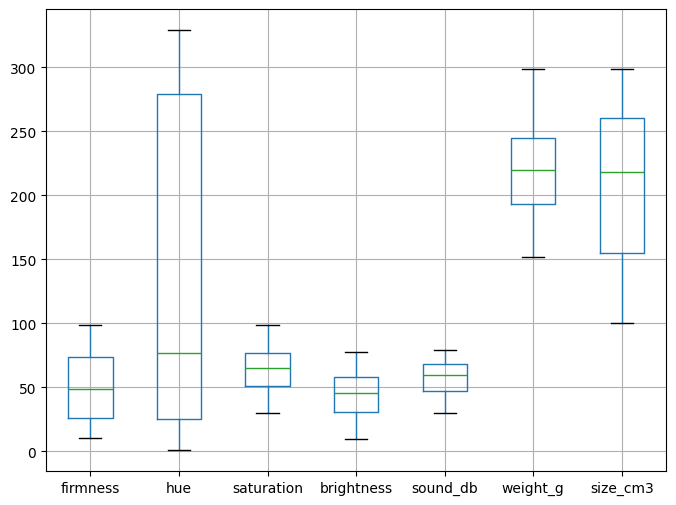

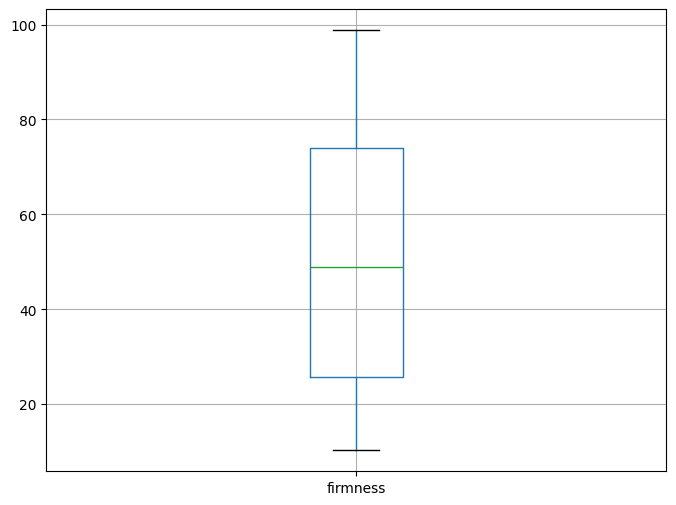

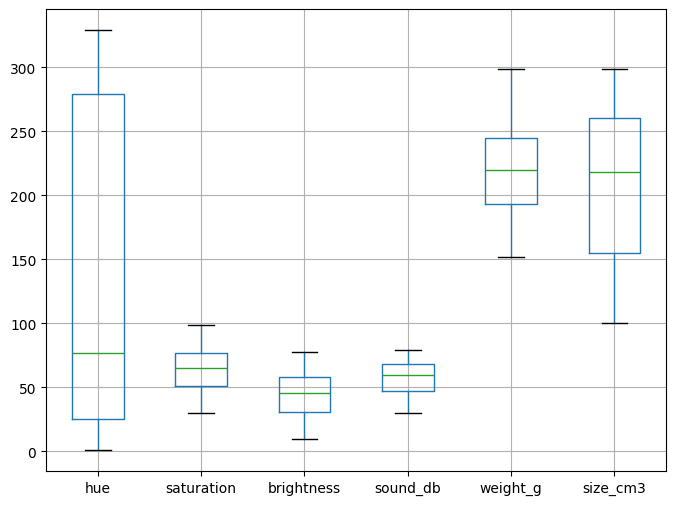

In [6]:
# 2.	Анализ распределения каждого признака (гистограммы, boxplots).
plt.figure(figsize=(8, 6))
df.select_dtypes(exclude='object',).boxplot()
plt.figure(figsize=(8, 6))
df.select_dtypes(exclude='int64',).boxplot()
plt.figure(figsize=(8, 6))
df.select_dtypes(exclude='float64',).boxplot()
plt.show()


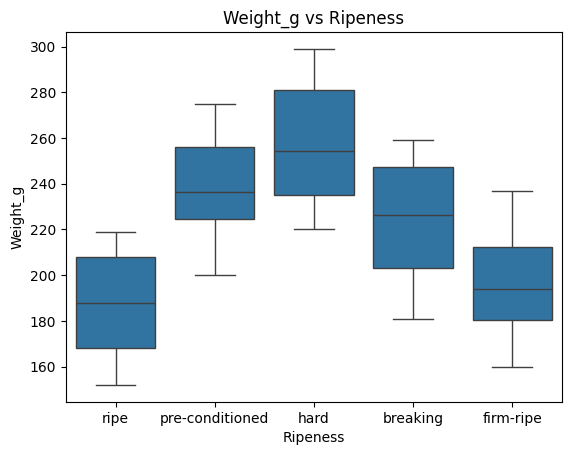

In [7]:
# 3.Анализ зависимости признаков от ripeness:
# weight_g vs ripeness
sns.boxplot(x='ripeness', y='weight_g', data=df)
plt.title('Weight_g vs Ripeness')
plt.xlabel('Ripeness')
plt.ylabel('Weight_g')
plt.show()

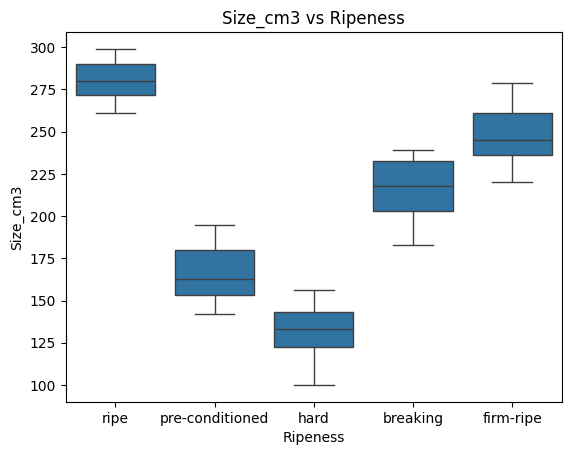

In [8]:
# size_cm3 vs ripeness
sns.boxplot(x='ripeness', y='size_cm3', data=df)
plt.title('Size_cm3 vs Ripeness')
plt.xlabel('Ripeness')
plt.ylabel('Size_cm3')
plt.show()

<Axes: >

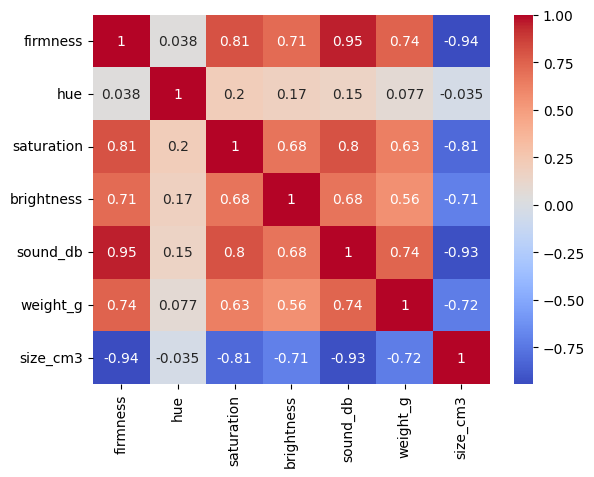

In [9]:
# 4.	Анализ корреляций между числовыми признаками (heatmap, pairplot)
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')

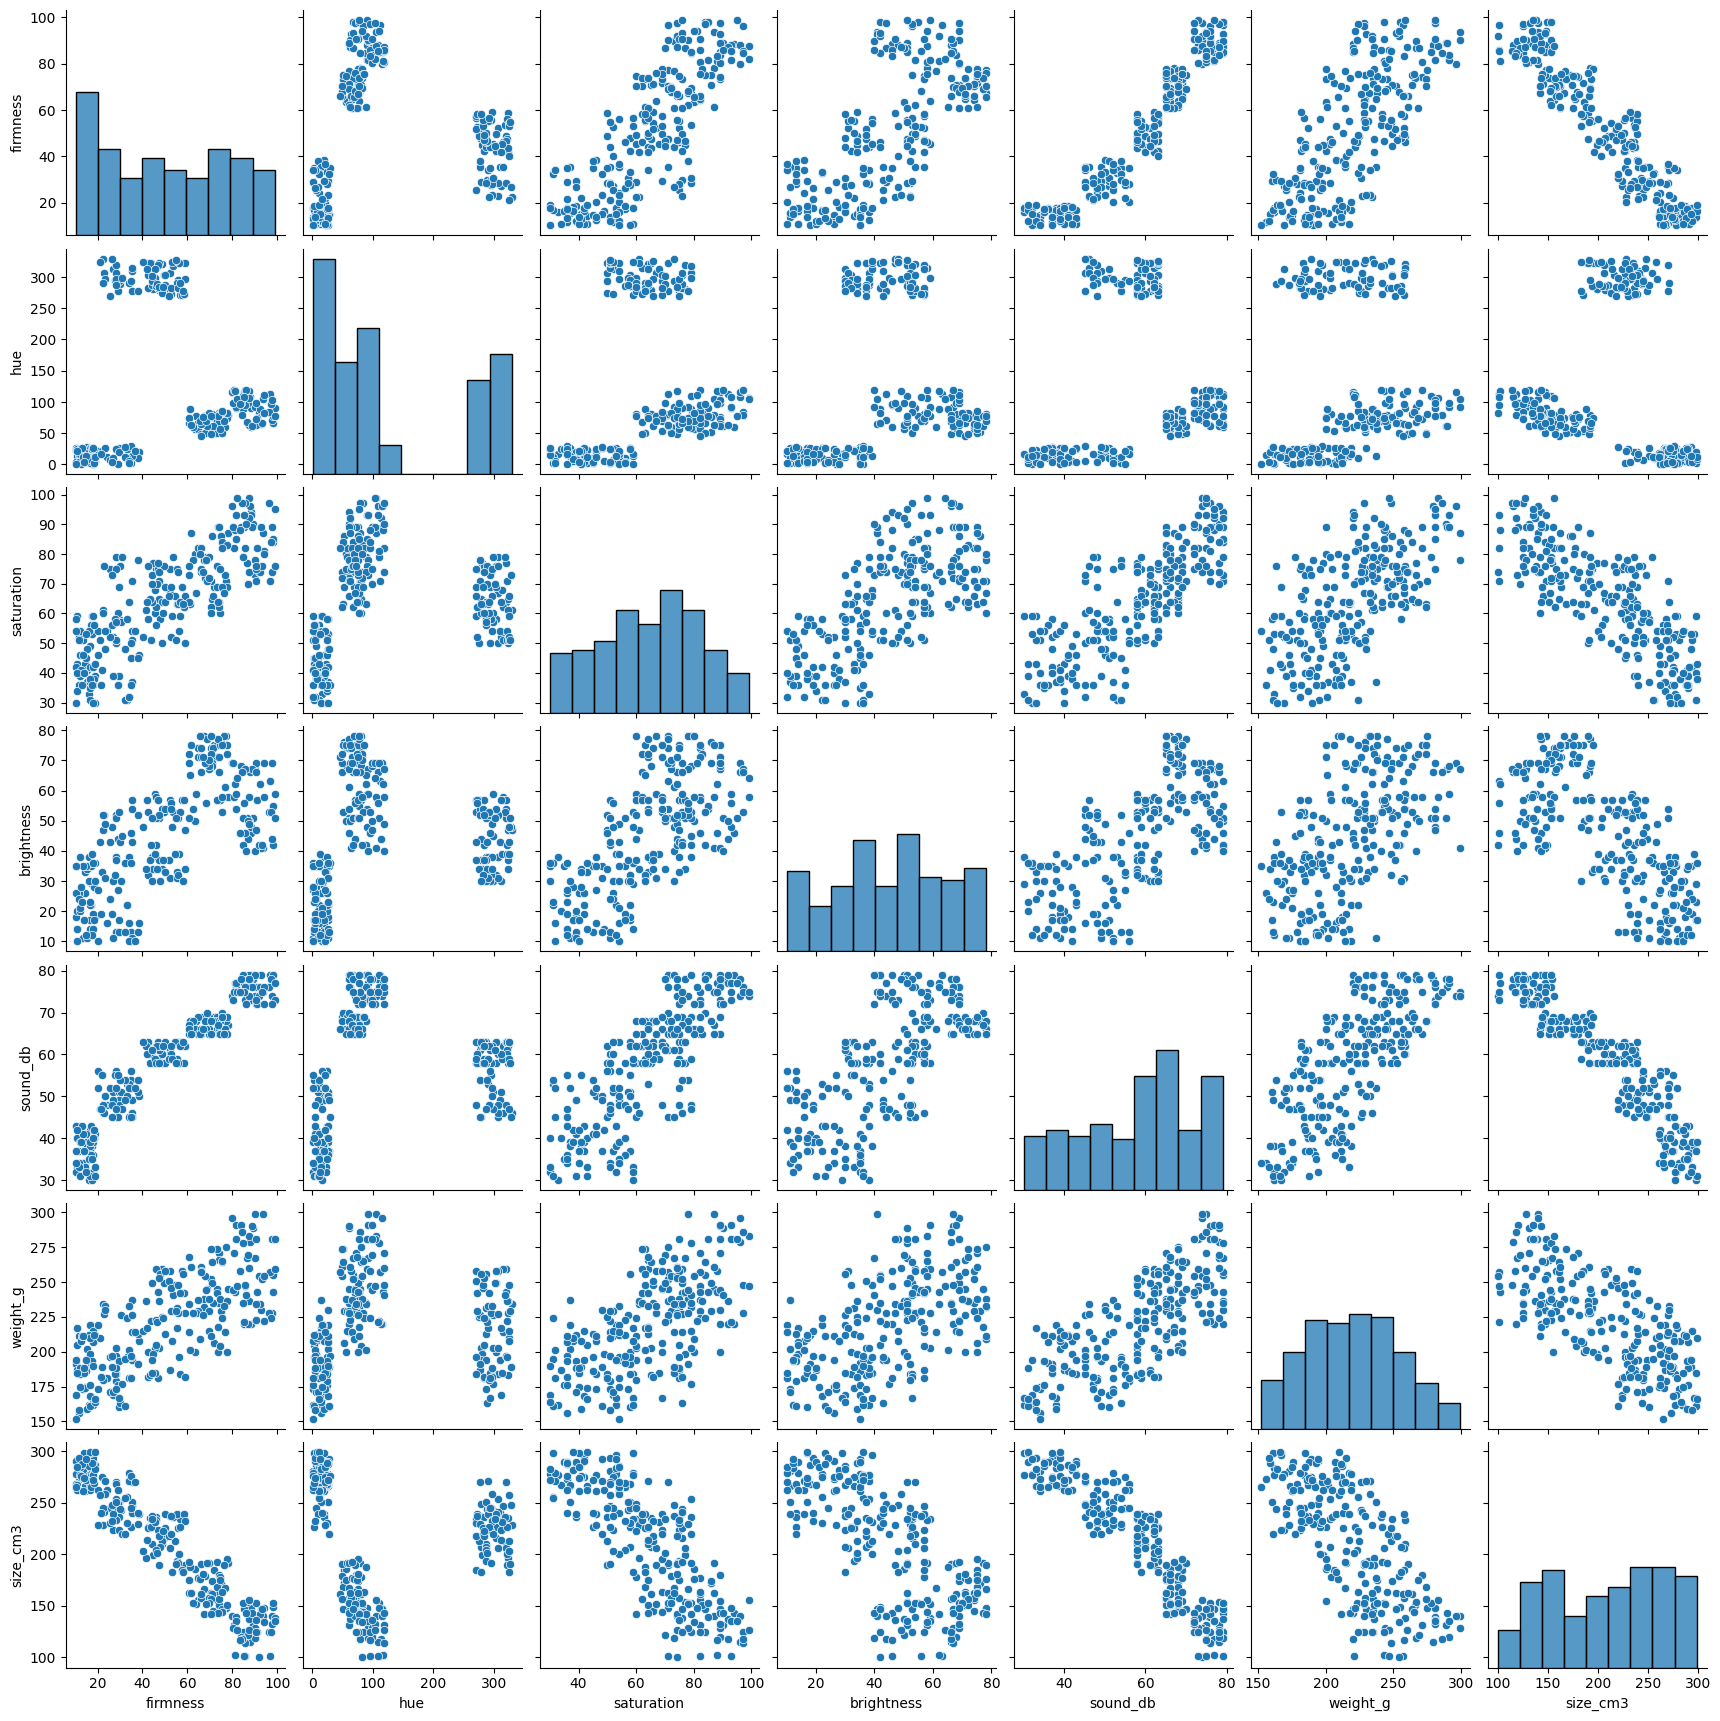

In [10]:
sns.pairplot(df)
plt.show()


In [11]:
# 5.	Проверка и обработка пропусков, выбросов.
df.isnull().sum()

,0
firmness,0
hue,0
saturation,0
brightness,0
color_category,0
sound_db,0
weight_g,0
size_cm3,0
ripeness,0


Этап 2: Предобработка данных

In [12]:
df['color_category']

,color_category
0,black
1,green
2,dark green
3,dark green
4,purple
...,...
245,dark green
246,black
247,black
248,green


In [13]:
ripeness_map = {'hard': 1, 'pre-conditioned': 2, 'breaking': 3, 'firm-ripe': 4, 'ripe': 5}
df['ripeness'] = df['ripeness'].map(ripeness_map)

In [14]:
#  6.	Кодирование категориальных признаков (color_category) — OneHot или Label Encoding.
df = pd.get_dummies(df, columns=['color_category'], drop_first=True).astype(int)

In [15]:
df.dtypes

,0
firmness,int64
hue,int64
saturation,int64
brightness,int64
sound_db,int64
weight_g,int64
size_cm3,int64
ripeness,int64
color_category_dark green,int64
color_category_green,int64


In [16]:
# 7.	Масштабирование числовых признаков (MinMaxScaler, StandardScaler).
scaler  = StandardScaler()
scaler_data = scaler.fit_transform(df.drop(columns='ripeness'))
scaler_data

array([[-1.32904775, -0.91480846, -1.4044229 , ..., -0.5       ,
        -0.5       , -0.65465367],
       [ 0.76573496, -0.62396945,  0.26778371, ..., -0.5       ,
         2.        , -0.65465367],
       [ 1.39049471, -0.56409082,  1.70934113, ...,  2.        ,
        -0.5       , -0.65465367],
       ...,
       [-1.32904775, -1.04311979, -1.4044229 , ..., -0.5       ,
        -0.5       , -0.65465367],
       [ 0.39822922, -0.53842856,  1.30570505, ..., -0.5       ,
         2.        , -0.65465367],
       [-1.21879603, -0.84637575, -1.98104587, ..., -0.5       ,
        -0.5       , -0.65465367]])

In [17]:
df.drop(columns='ripeness').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   firmness                   250 non-null    int64
 1   hue                        250 non-null    int64
 2   saturation                 250 non-null    int64
 3   brightness                 250 non-null    int64
 4   sound_db                   250 non-null    int64
 5   weight_g                   250 non-null    int64
 6   size_cm3                   250 non-null    int64
 7   color_category_dark green  250 non-null    int64
 8   color_category_green       250 non-null    int64
 9   color_category_purple      250 non-null    int64
dtypes: int64(10)
memory usage: 19.7 KB


In [18]:
x = scaler_data
y = df['ripeness']

In [19]:
# 8.	Формирование X и y (разделение признаков и целевой переменной).
x_train,  x_test,  y_train,  y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [21]:
#9.	Разделение на обучающую и тестовую выборки (например, 80/20).
X = df.drop('ripeness', axis=1)
y = df['ripeness']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (200, 10) (200,)
Test: (50, 10) (50,)


Этап 3: Моделирование

In [22]:
# 10.	Обучение нескольких моделей классификации:
# o	Logistic Regression (базовая модель)
# o	Random Forest Classifier (основная модель)
# o	(по желанию: XGBoost, LightGBM)
model = LogisticRegression(random_state=42)
model.fit(x_train, y_train)

LogisticRegression(random_state=42)

In [23]:
y_pred = model.predict(x_test)

In [24]:
# 11.	Оценка моделей:
# o	Accuracy
accuracy_score(y_test, y_pred)

1.0

In [25]:
df.describe()

,firmness,hue,saturation,brightness,sound_db,weight_g,size_cm3,ripeness,color_category_dark green,color_category_green,color_category_purple
count,250.000000,250.00000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,50.164000,125.94400,64.356000,45.07200,58.016000,220.188000,208.644000,3.000000,0.200000,0.200000,0.300000
std,27.265044,117.13767,17.377144,19.11629,13.838126,34.405225,55.940564,1.417051,0.400802,0.400802,0.459177
min,10.000000,1.00000,30.000000,10.00000,30.000000,152.000000,100.000000,1.000000,0.000000,0.000000,0.000000
25%,25.250000,25.25000,51.250000,31.00000,47.250000,193.250000,155.250000,2.000000,0.000000,0.000000,0.000000
50%,48.500000,77.00000,65.000000,46.00000,60.000000,220.000000,218.000000,3.000000,0.000000,0.000000,0.000000
75%,73.750000,278.75000,76.750000,58.00000,68.000000,245.000000,260.500000,4.000000,0.000000,0.000000,1.000000
max,98.000000,329.00000,99.000000,78.00000,79.000000,299.000000,299.000000,5.000000,1.000000,1.000000,1.000000


In [26]:
df.describe().round()

,firmness,hue,saturation,brightness,sound_db,weight_g,size_cm3,ripeness,color_category_dark green,color_category_green,color_category_purple
count,250.0,250.0,250.0,250.0,250.0,250.0,250.0,250.0,250.0,250.0,250.0
mean,50.0,126.0,64.0,45.0,58.0,220.0,209.0,3.0,0.0,0.0,0.0
std,27.0,117.0,17.0,19.0,14.0,34.0,56.0,1.0,0.0,0.0,0.0
min,10.0,1.0,30.0,10.0,30.0,152.0,100.0,1.0,0.0,0.0,0.0
25%,25.0,25.0,51.0,31.0,47.0,193.0,155.0,2.0,0.0,0.0,0.0
50%,48.0,77.0,65.0,46.0,60.0,220.0,218.0,3.0,0.0,0.0,0.0
75%,74.0,279.0,77.0,58.0,68.0,245.0,260.0,4.0,0.0,0.0,1.0
max,98.0,329.0,99.0,78.0,79.0,299.0,299.0,5.0,1.0,1.0,1.0


In [27]:
#14.	Сериализация модели (joblib или pickle).
joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']